In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from matplotlib.lines import Line2D
from sklearn.feature_selection import f_regression
from statsmodels.stats.outliers_influence import variance_inflation_factor
from tqdm import tqdm

plt.rcParams.update({'font.size': 20})
sns.set_style("darkgrid")

In [2]:
df_x = pd.read_csv('../dataset/1-preprocessed/X.csv')
df_y = pd.read_csv('../dataset/1-preprocessed/y.csv')
df = df_x.merge(df_y).drop(['id', 'faulty'], axis=1)
base_features = ['oat', 'mgt', 'np', 'pa', 'ias', 'ng', 'trq_measured']
df_x.drop('id', axis=1, inplace=True)

## Multicollinearity test using VIF

*np* and *ng* are strongly inversely correlated.

#### $$np\approx  -1.06\times ng + 165$$

Why "inversely"?

Think of the engine like a shared power source with two "users" — the rotor and the compressor:

    When the rotor draws a lot of power (like adding load to an electric generator), there’s less left for the compressor.
    When the rotor draws little power, the compressor can "take more" of the engine's energy.

In [4]:
def calculate_vif(data, samples=10_000):
    vif_df = data.assign(const=1)
    vif = []
    for i in tqdm(range(vif_df.shape[1])):
        vif.append(variance_inflation_factor(vif_df.values[:samples], i))

    vif_data = pd.Series(vif, index=vif_df.columns)
    vif_data = vif_data[vif_data.index != 'const']
    plt.figure(figsize=(22, 5))
    ax = sns.barplot(x=vif_data.index, y=vif_data, hue=vif_data, palette='viridis', legend=False)
    ax.add_line(Line2D([-1, len(vif_data)], [5] * 2, linestyle='--', color='r', linewidth=2))
    ax.set_xlabel('Features')
    return vif_data

100%|██████████| 8/8 [00:00<00:00, 51.57it/s]


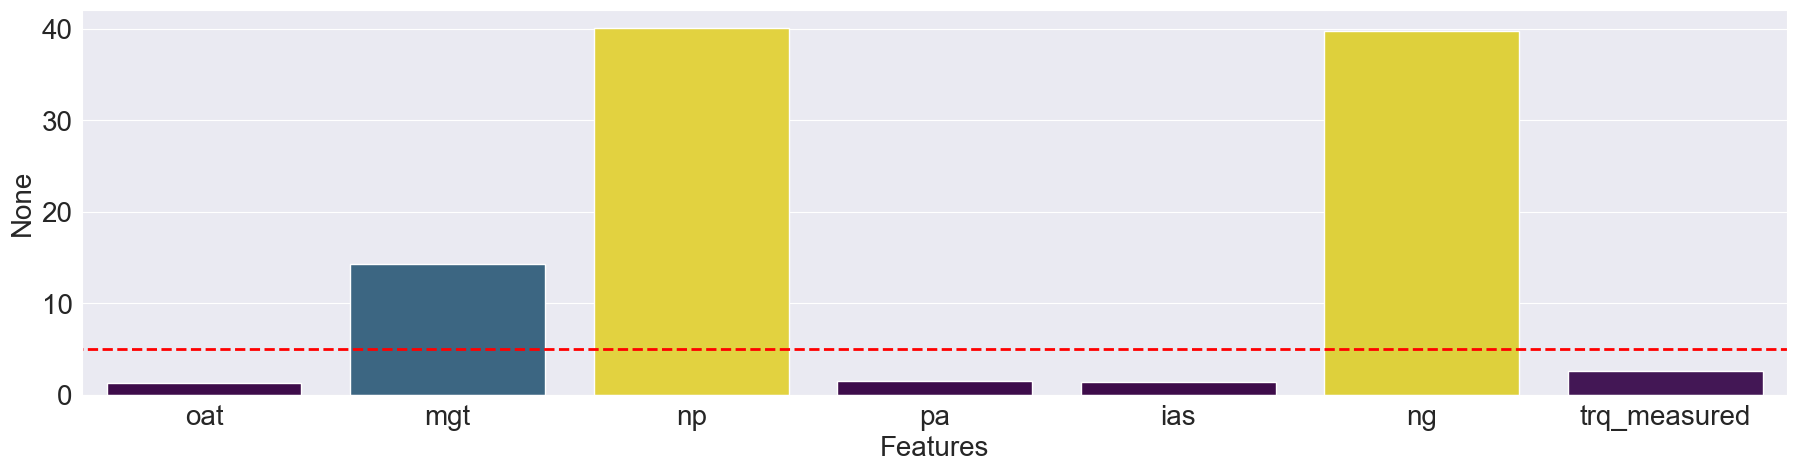

In [233]:
vif_df = df[['oat', 'mgt', 'np', 'pa', 'ias', 'ng', 'trq_measured']]
calculate_vif(vif_df)

In [150]:
osl_x = vif_df.drop(columns=['np']).assign(const=1)
osl_y = df['np']
np_osl_model = sm.OLS(osl_y, osl_x).fit()
print(np_osl_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     np   R-squared:                       0.975
Model:                            OLS   Adj. R-squared:                  0.975
Method:                 Least Squares   F-statistic:                 4.831e+06
Date:                Tue, 11 Mar 2025   Prob (F-statistic):               0.00
Time:                        22:31:04   Log-Likelihood:            -7.1261e+05
No. Observations:              742625   AIC:                         1.425e+06
Df Residuals:                  742618   BIC:                         1.425e+06
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
oat             -0.0006      0.000     -5.867   

-0.7891654004519081

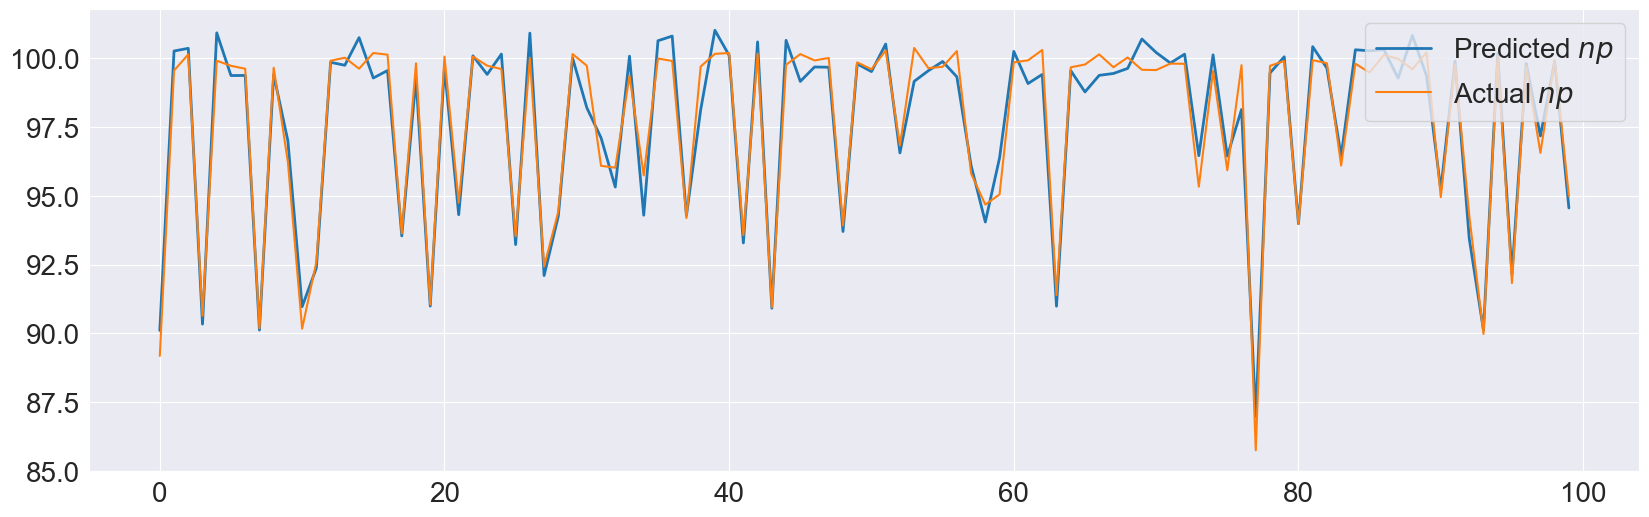

In [179]:
ax = pd.Series(np_osl_model.predict()[:100]).plot(figsize=(20, 6), label='Predicted $np$', linewidth=2)
(df['np'][:100]).plot(ax=ax, label='Actual $np$')
ax.legend(loc='upper right')
df['ng'].corr(df['np'])

## Correlation pruning
Prior to feature selection, we're going to prune highly correlated (thus most probably redundant) features.

In [5]:
correlation_matrix = df.drop(base_features, axis=1).corr()

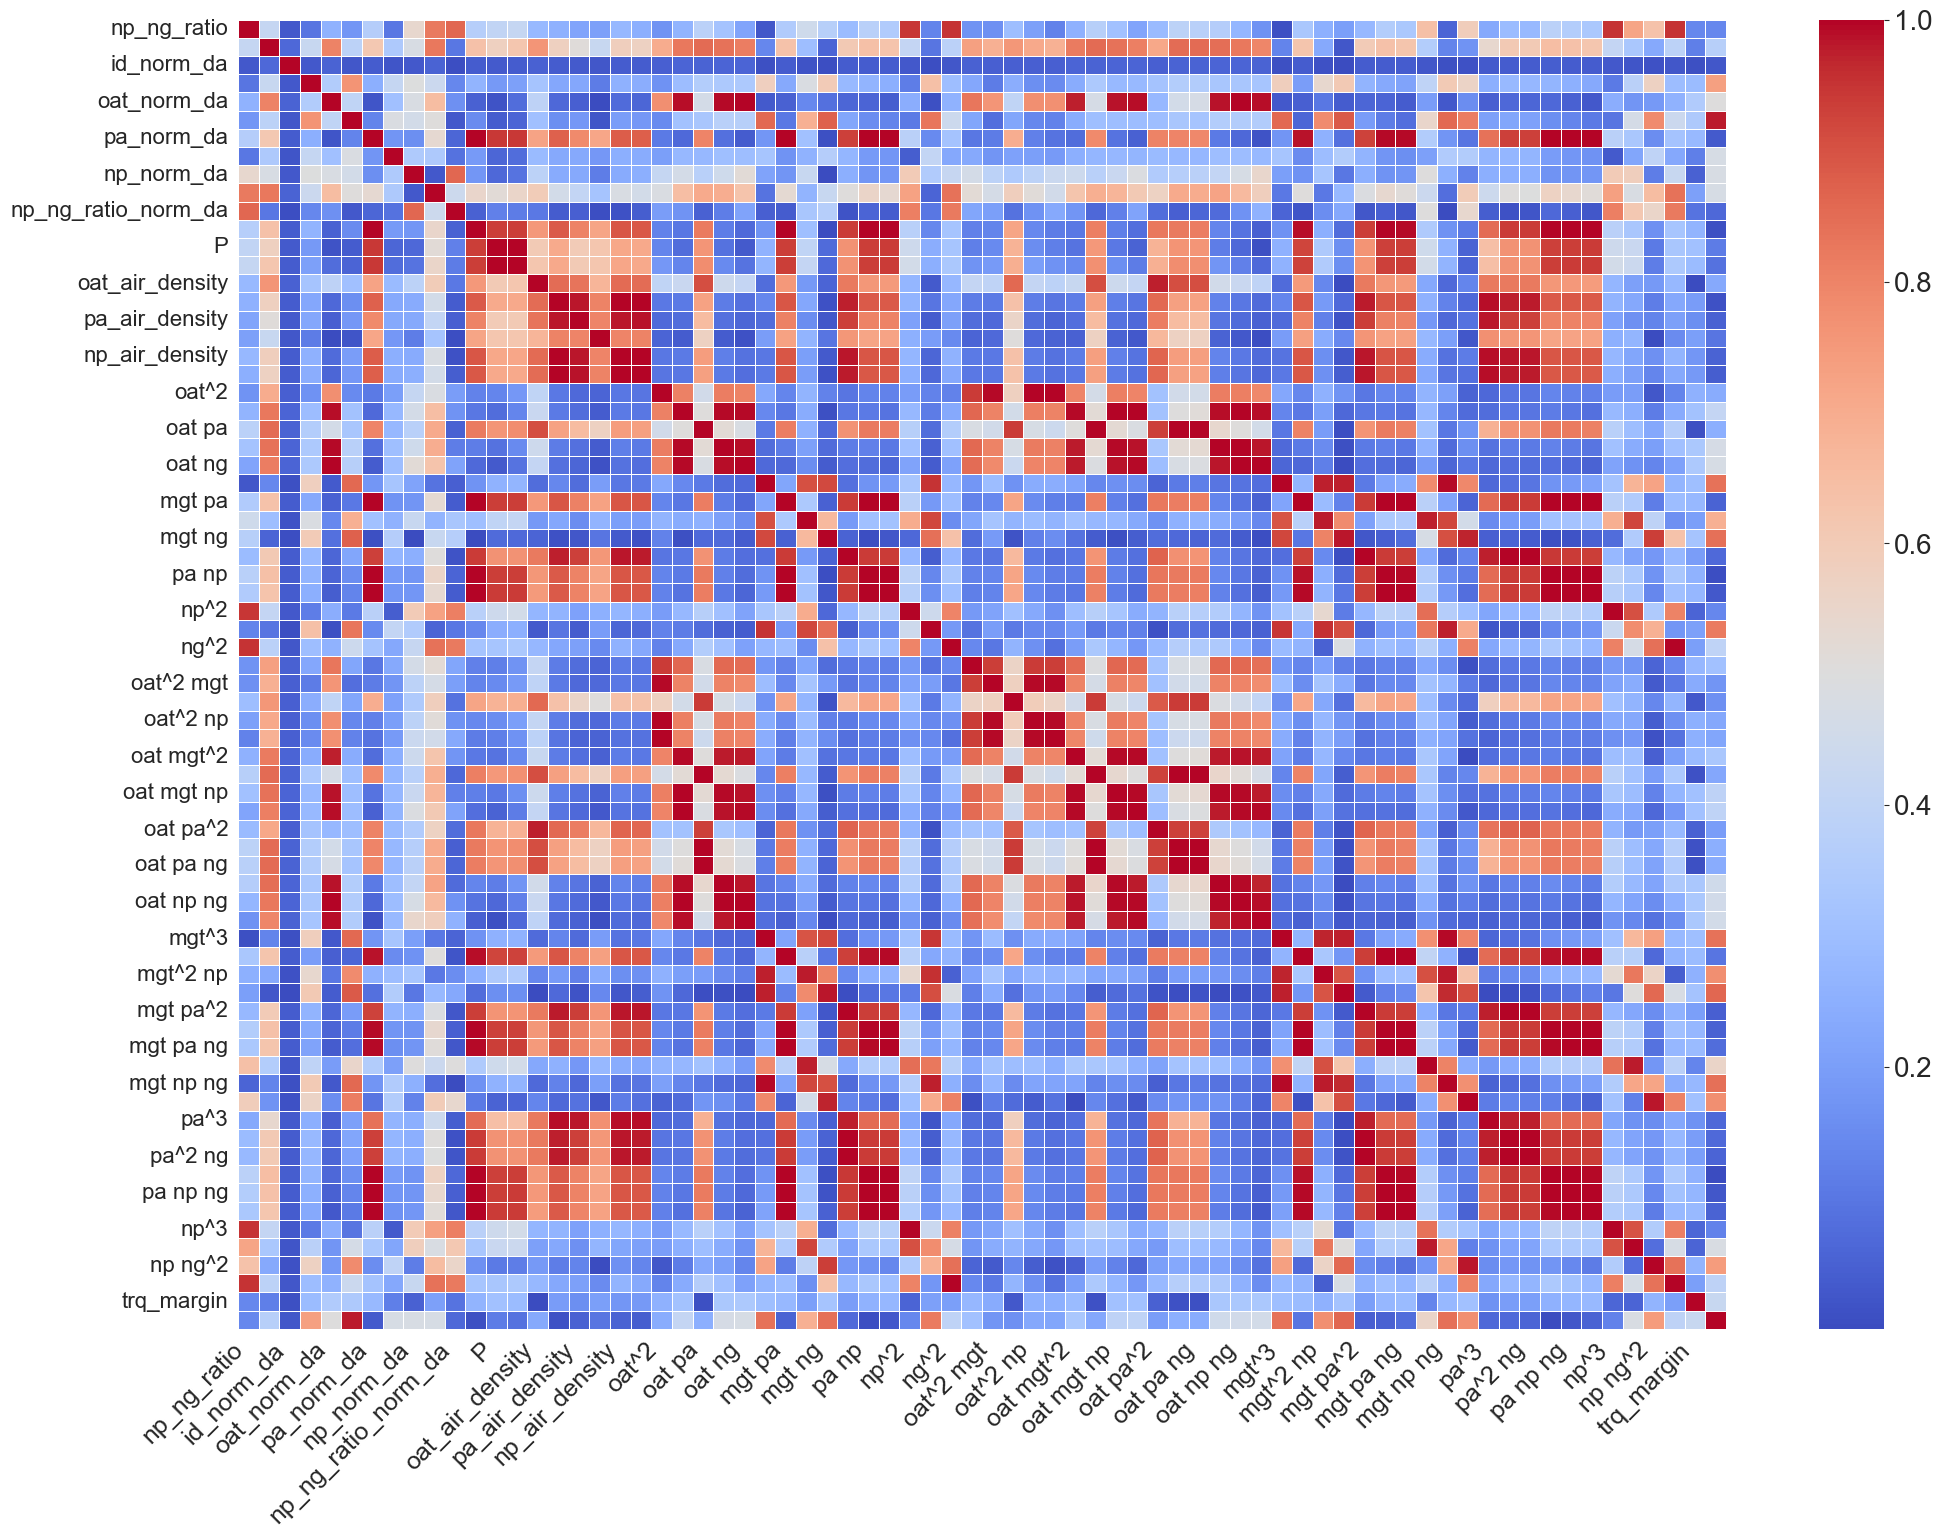

In [6]:
plt.figure(figsize=(24, 17))
sns.heatmap(correlation_matrix.abs(), annot=False, fmt=".2f", linewidths=0.4, cbar=True, cmap='coolwarm')
plt.xticks(rotation=45, ha="right", fontsize=18)
plt.yticks(fontsize=16)
plt.show()

### Why are "air_density" features almost perfectly correlated?
Because they have a small variability compared to that of $\rho$.

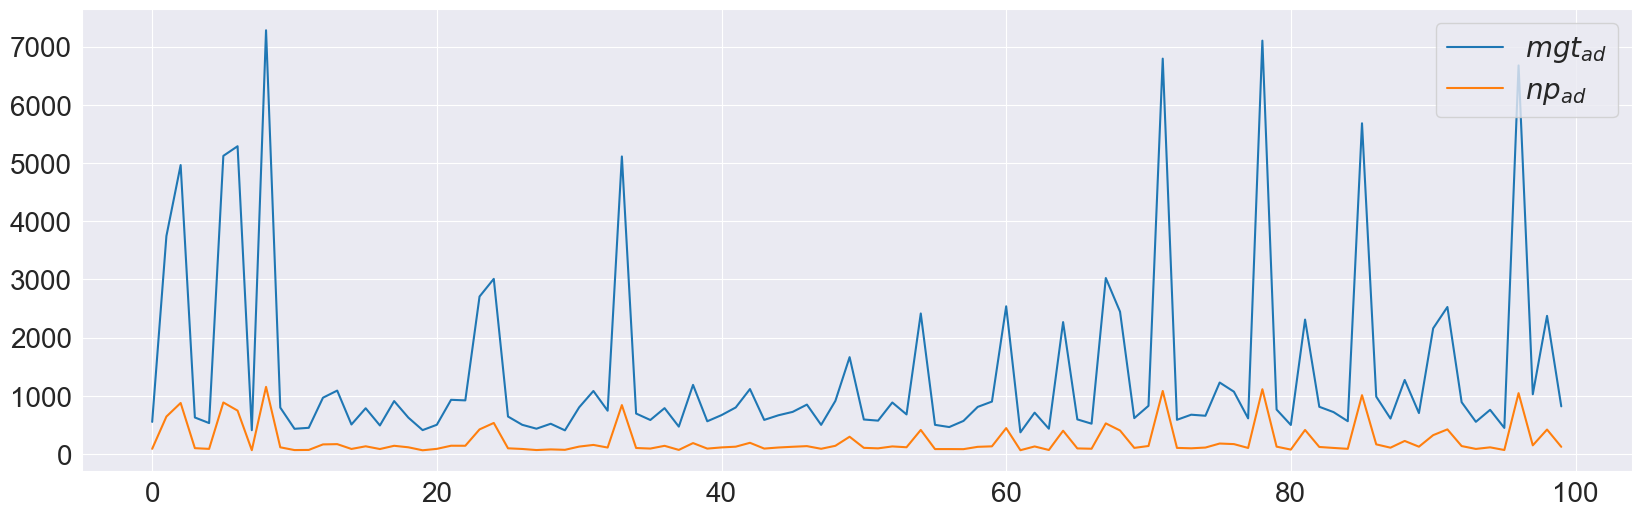

In [67]:
ax = df['mgt_air_density'][:100].plot(figsize=(20, 6), label='$mgt_{ad}$')
(df['np_air_density'][:100]).plot(ax=ax, label='$np_{ad}$')
ax.legend(loc='upper right')

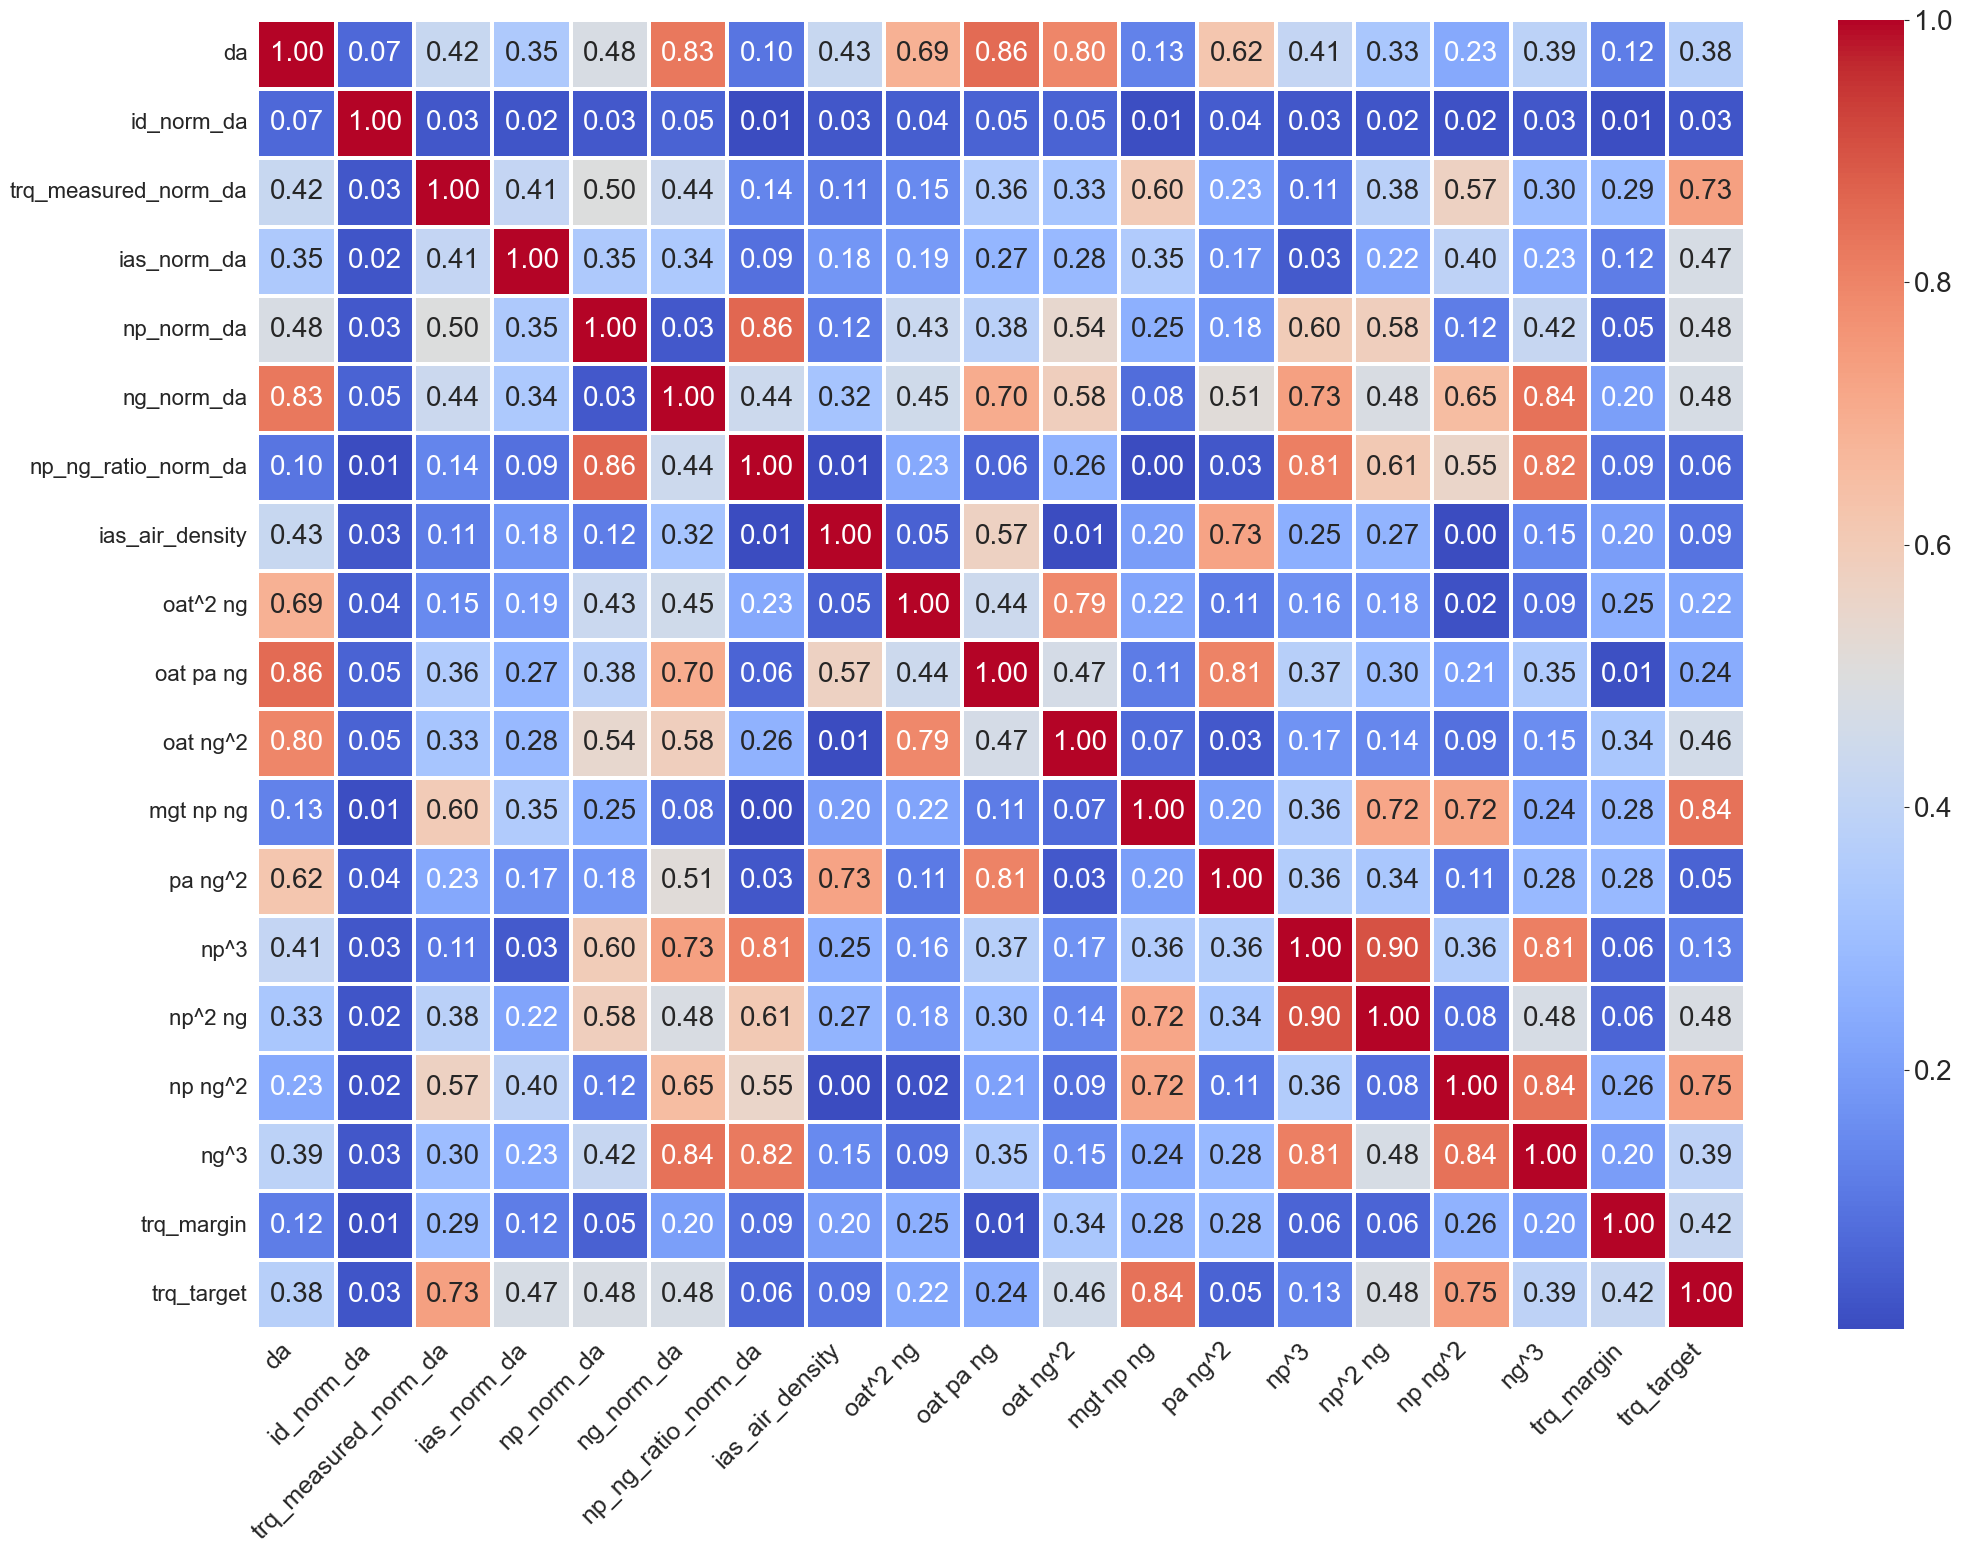

In [7]:
threshold = 0.925

# Find pairs of highly correlated features
high_corr_pairs = set()
for i in range(len(correlation_matrix.columns)):
    for j in range(i):
        if abs(correlation_matrix.iloc[i, j]) > threshold:
            high_corr_pairs.add((correlation_matrix.columns[i], correlation_matrix.columns[j]))

# Determine which features to drop (just pick one from each pair)
features_to_drop = set([pair[1] for pair in high_corr_pairs])

plt.figure(figsize=(24, 17))
pruned_correlation_matrix = correlation_matrix.drop(features_to_drop, axis=0).drop(features_to_drop, axis=1).abs()
sns.heatmap(pruned_correlation_matrix, annot=True, fmt=".2f", linewidths=1.5, cbar=True, cmap='coolwarm')
plt.xticks(rotation=45, ha="right", fontsize=18)
plt.yticks(fontsize=16)
plt.show()

## Correlation with target
Dropping features that are less correlated with the target is based on the idea that features with little or no relationship to the outcome are unlikely to improve—and might even harm—the predictive performance of the model.

Features with low correlation might be dropped, but we must remember to check for multicollinearity among features as well.

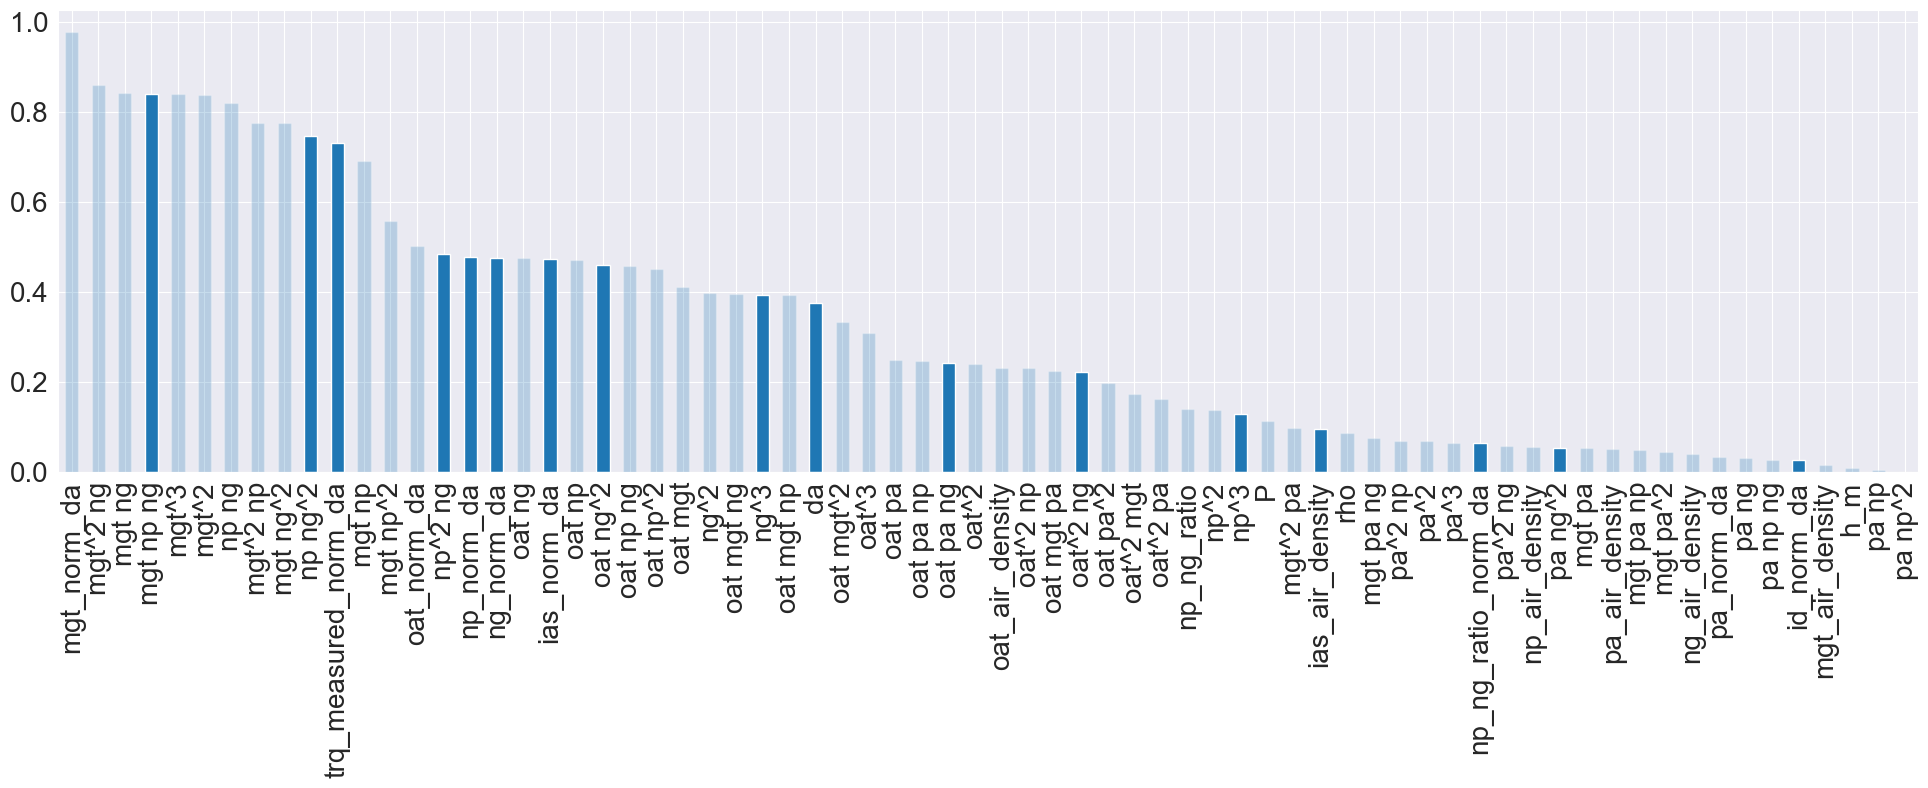

In [8]:
target_correlations = (correlation_matrix['trq_target'].drop(['trq_margin', 'trq_target']).abs()
                       .sort_values(ascending=False))
plt.figure(figsize=(24, 6))
ax = target_correlations.plot(kind='bar')
alphas = [0.25 if x in features_to_drop else 1.0 for x in target_correlations.index]
for bar, alpha in zip(ax.patches, alphas):
    bar.set_alpha(alpha)


## ANOVA F-test ranking
Evaluates whether each feature has a significant linear relationship with the target. **In a nutshell it computes the cross-correlation between each feature and the target and finds the probability of the null-Hp using the Fisher distribution**. A high F-score (with a corresponding low p-value) indicates that the feature is more likely to be significantly associated with the target variable

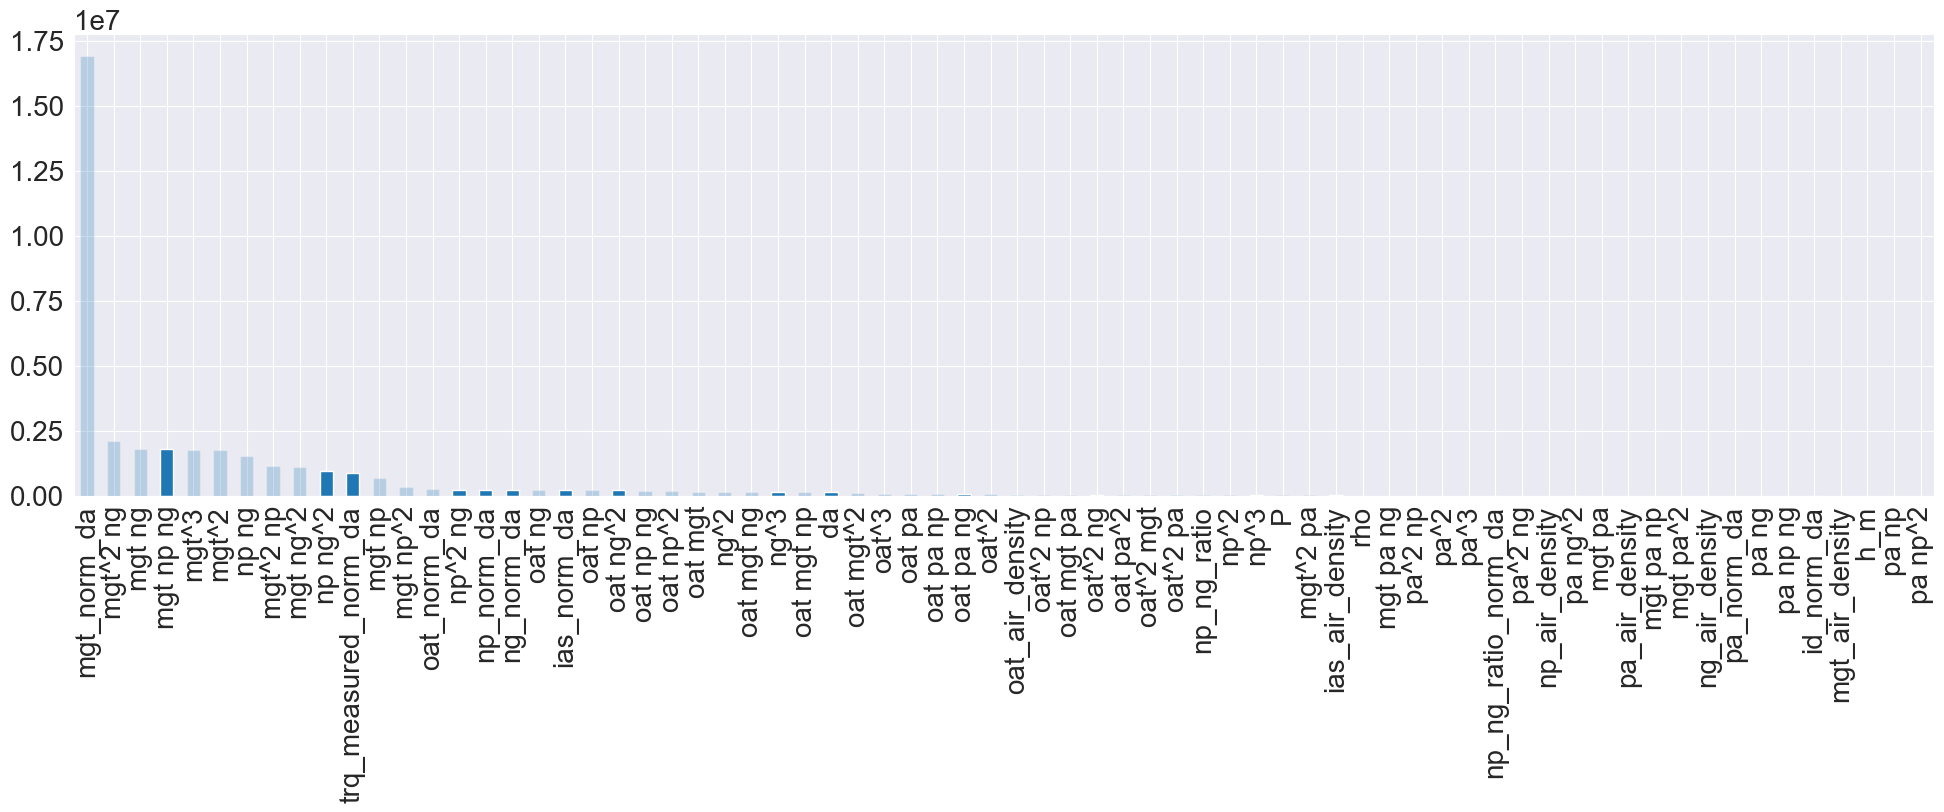

In [9]:
F, p_values = f_regression(df_x.drop(base_features, axis=1), df['trq_target'])
f_scores = pd.Series(F, index=df_x.drop(base_features, axis=1).columns).sort_values(ascending=False)
ax = f_scores.plot(kind='bar', figsize=(24, 6))
for bar, alpha in zip(ax.patches, alphas):
    bar.set_alpha(alpha)

## Comparing the results of the two indicators and selecting the features

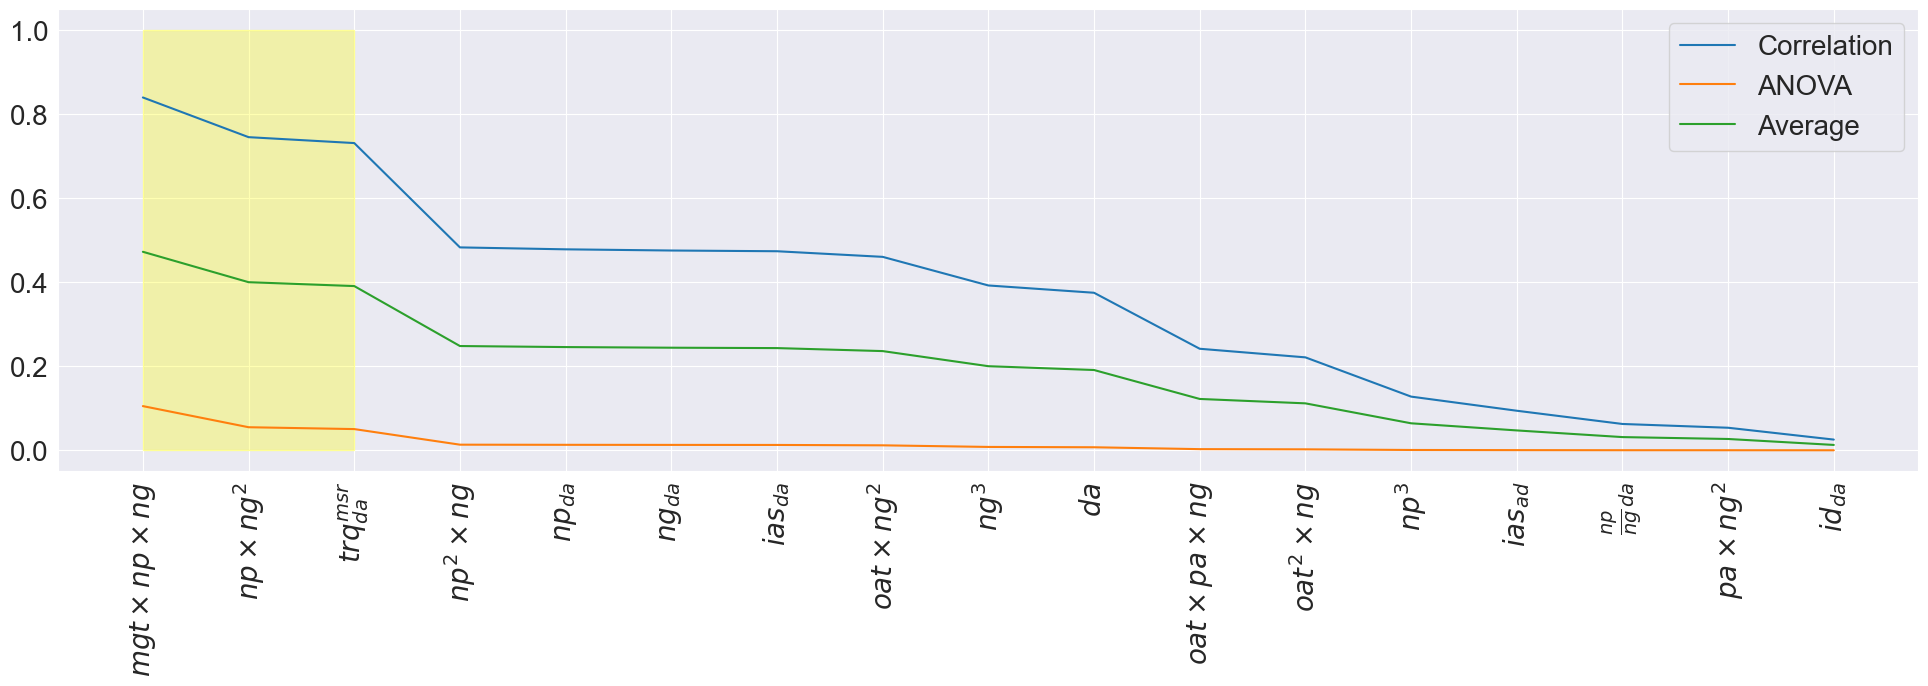

In [66]:
def formatter(feature: str):
    feature = feature.replace(" ", "\\times ").replace("norm_air_density", "{ad}").replace("norm_da", "{da}").replace(
        "air_density", "{ad}").replace("np_ng_ratio", "\\frac{np}{ng}").replace("_measured", "^{msr}")
    return f"${feature}$"


features_to_keep = 3
result1 = np.abs(target_correlations)
result2 = f_scores / f_scores.max()
mean_result = (result1 + result2) / 2
result = (pd.DataFrame({'Correlation': result1, 'ANOVA': result2, 'Average': mean_result})
          .sort_values(by='Average', ascending=False).drop(features_to_drop))
selected_features_df = df_x[result.index.values[:features_to_keep]]
ax = result.plot(kind='line', figsize=(24, 6))
ax.set_xticks(range(len(result.index)))
ax.set_xticklabels(map(formatter, result.index), rotation=90)
ax.fill_between(range(features_to_keep), 1, alpha=0.3, color='yellow')
plt.show()

In [137]:
selected_features_df.to_csv('../dataset/2-regression/X2.csv', index=False)
df_y[['trq_target']].to_csv('../dataset/2-regression/y.csv', index=False)